In [ ]:
import tifffile
import numpy as np 
import matplotlib.pyplot as plt 
import os 


# AKOYA_ISILON and _DB are derived from the local environ
ISILON_BASE = "/home/boyesh/IMLAkoyafusion"
DB_PATH = "/home/boyesh/akoya_pcf/akoya_db"

In [8]:
with tifffile.TiffFile(f"{ISILON_BASE}/prototype/052024 P7HuP120 #03 SG03_Scan1.unmixed.qptiff") as tif:
    series = tif.series[0]
    dapi = series.pages[0].asarray()

In [9]:
print(dapi.shape)
print(f"Min: {dapi.min()}, Max: {dapi.max()}, Mean: {dapi.mean()}")

(37440, 30720)
Min: 0, Max: 567, Mean: 11.379804032806657


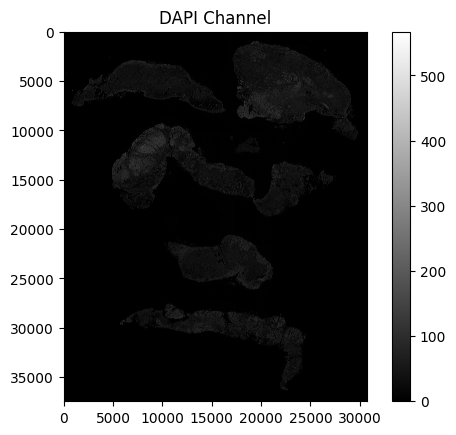

In [10]:
plt.imshow(dapi, cmap='gray')
plt.title("DAPI Channel")
plt.colorbar()
plt.show()

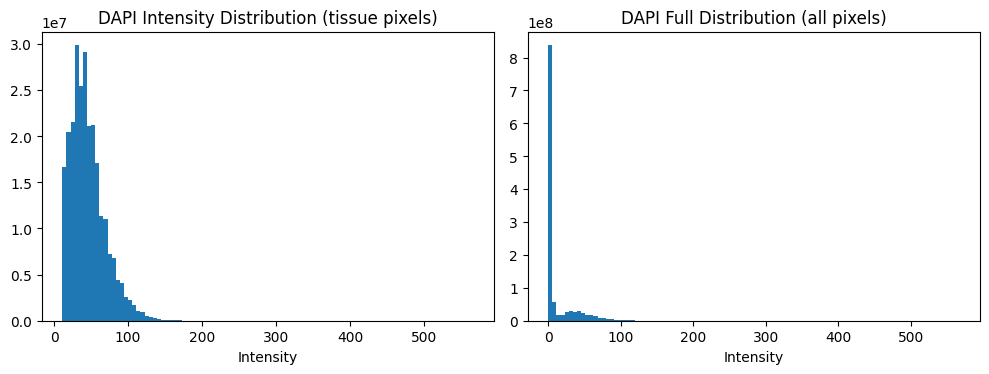

In [14]:
tissue_pixels = dapi[dapi>10]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(tissue_pixels, bins=100)
plt.title("DAPI Intensity Distribution (tissue pixels)")
plt.xlabel("Intensity")

plt.subplot(1, 2, 2)
plt.hist(dapi.flatten(), bins=100)
plt.title("DAPI Full Distribution (all pixels)")
plt.xlabel("Intensity")

plt.tight_layout()
plt.show()

In [15]:
background = np.percentile(dapi, 5)
dapi_corrected = np.clip(dapi - background, 0, None)

print(f"Background estimate: {background}")
print (f"Corrected min: {dapi_corrected.min()}, max: {dapi_corrected.max()}")

Background estimate: 0.0
Corrected min: 0.0, max: 567.0


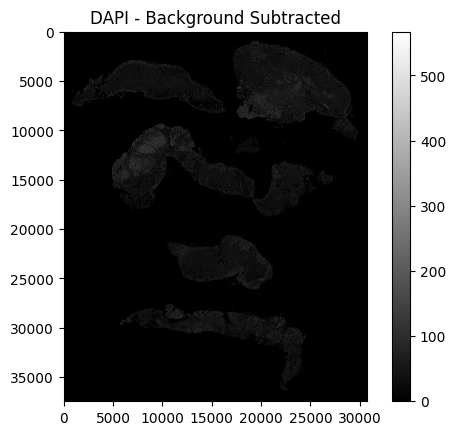

In [16]:
plt.imshow(dapi_corrected, cmap='gray')
plt.title("DAPI - Background Subtracted")
plt.colorbar()
plt.show()

Opal 480 - Min: 0, Max: 1520, Background Estimate: 0.0


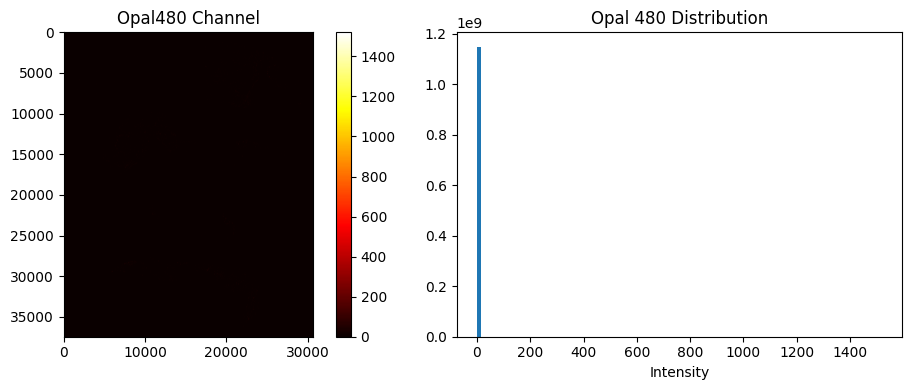

In [19]:
with tifffile.TiffFile(f"{ISILON_BASE}/prototype/052024 P7HuP120 #03 SG03_Scan1.unmixed.qptiff") as tif:
    opal480 = tif.series[0].pages[1].asarray()

background = np.percentile(opal480, 5)
print(f"Opal 480 - Min: {opal480.min()}, Max: {opal480.max()}, Background Estimate: {background}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(opal480, cmap='hot')
plt.title("Opal480 Channel")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.hist(opal480.flatten(), bins=100)
plt.title("Opal 480 Distribution")
plt.xlabel("Intensity")
plt.tight_layout()
plt.show()


In [21]:
import sys
sys.path.append("/home/boyesh/akoya_pcf")
from scripts.preprocessing import process_slide

results = process_slide(f"{ISILON_BASE}/prototype/052024 P7HuP120 #03 SG03_Scan1.unmixed.qptiff")

for r in results:
    print(f"Channel {r['channel_index']} — Flagged: {r['flagged']} ({r['flag_message']}) — Nonzero: {r['stats']['nonzero_fraction']:.4f}")

Channel 0 — Flagged: False (Signal OK) — Nonzero: 0.5639
Channel 1 — Flagged: True (Low signal detected) — Nonzero: 0.0032
Channel 2 — Flagged: True (Low signal detected) — Nonzero: 0.0052
Channel 3 — Flagged: False (Signal OK) — Nonzero: 0.0965
Channel 4 — Flagged: False (Signal OK) — Nonzero: 0.3369
Channel 5 — Flagged: False (Signal OK) — Nonzero: 0.1617
Channel 6 — Flagged: False (Signal OK) — Nonzero: 0.2246
Channel 7 — Flagged: False (Signal OK) — Nonzero: 0.6538
